# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** [Isi Nama Anda]
- **Email:** [Isi Email Anda]
- **ID Dicoding:** [Isi Username Dicoding Anda]

Proyek ini menganalisis pola penyewaan sepeda Capital Bikeshare di Washington D.C. selama periode **1 Januari 2011 sampai 31 Desember 2012**. Data utama yang digunakan adalah `hour.csv` karena memiliki granularitas per jam sehingga cocok untuk menganalisis waktu permintaan tertinggi dan dampak kondisi cuaca.

## Menentukan Pertanyaan Bisnis

Pertanyaan berikut disusun menggunakan prinsip **SMART**: spesifik, terukur, berorientasi aksi, relevan dengan operasional bike sharing, dan memiliki batas waktu yang jelas.

- **Pertanyaan 1:** Selama periode **1 Januari 2011–31 Desember 2012**, pada jam berapa **rata-rata penyewaan sepeda per jam** mencapai nilai tertinggi pada **hari kerja** dibandingkan **hari non-kerja**, dan bagaimana pola tersebut dapat digunakan untuk menentukan waktu prioritas ketersediaan sepeda?
- **Pertanyaan 2:** Selama periode **1 Januari 2011–31 Desember 2012**, bagaimana perbedaan **rata-rata penyewaan sepeda per jam** pada setiap **kondisi cuaca**, dan seberapa besar perubahan permintaan dibandingkan kondisi cuaca cerah untuk mendukung perencanaan kapasitas operasional?

### Alasan pertanyaan memenuhi SMART

- **Specific:** fokus pada waktu penggunaan, tipe hari, dan kondisi cuaca.
- **Measurable:** menggunakan metrik rata-rata jumlah penyewaan (`cnt`) per jam dan persentase perubahan.
- **Action-Oriented:** hasil dapat digunakan untuk penempatan sepeda, penjadwalan rebalancing, dan kapasitas layanan.
- **Relevant:** ketersediaan sepeda harus mengikuti pola permintaan pengguna.
- **Time-bound:** analisis dibatasi pada data 2011–2012.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

## Data Wrangling

### Gathering Data

Data utama dimuat dari `data/hour.csv`. File ini berisi catatan penyewaan sepeda per jam. `day.csv` tetap disertakan di folder `data` sebagai bagian dari dataset asli, tetapi analisis utama menggunakan data per jam agar pertanyaan bisnis dapat dijawab secara lebih rinci.

In [2]:
DATA_PATH = Path("data/hour.csv")
hour_df = pd.read_csv(DATA_PATH)

print("Ukuran data:", hour_df.shape)
display(hour_df.head())

Ukuran data: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight Gathering:**
- Dataset memiliki **17.379 baris** dan **17 kolom**.
- Variabel utama untuk analisis adalah `dteday`, `hr`, `workingday`, `weathersit`, `season`, `casual`, `registered`, dan `cnt`.
- Kolom `cnt` merupakan total penyewaan, yaitu penjumlahan pengguna `casual` dan `registered`.

### Assessing Data

Pada tahap ini dilakukan pemeriksaan tipe data, missing value, duplikasi, rentang nilai kategori, konsistensi total penyewaan, dan potensi outlier.

In [3]:
print("=== INFO DATA ===")
hour_df.info()

print("\n=== MISSING VALUE ===")
display(hour_df.isna().sum().to_frame("missing_value"))

print("Jumlah baris duplikat:", hour_df.duplicated().sum())
print("Duplikat kombinasi tanggal-jam:", hour_df.duplicated(subset=["dteday", "hr"]).sum())

print("\n=== NILAI UNIK KATEGORI ===")
for col in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]:
    print(col, sorted(hour_df[col].unique()))

print("\nKonsistensi cnt = casual + registered:", ((hour_df["casual"] + hour_df["registered"]) == hour_df["cnt"]).all())

q1 = hour_df["cnt"].quantile(0.25)
q3 = hour_df["cnt"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"Batas atas IQR cnt: {upper_bound:.1f}")
print("Jumlah nilai di atas batas IQR:", (hour_df["cnt"] > upper_bound).sum())

=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

=== MISSING VALUE ===


,missing_value
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Jumlah baris duplikat: 0
Duplikat kombinasi tanggal-jam: 0

=== NILAI UNIK KATEGORI ===
season [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr [np.int64(0), np.int64(1)]
mnth [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
hr [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
holiday [np.int64(0), np.int64(1)]
weekday [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
workingday [np.int64(0), np.int64(1)]
weathersit [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Konsistensi cnt = casual + registered: True
Batas atas IQR cnt: 642.5
Jumlah nilai di ata

**Masalah yang teridentifikasi dan langkah yang akan dilakukan:**
1. **Tipe data tanggal tidak tepat:** `dteday` terbaca sebagai `object`, padahal seharusnya bertipe `datetime`. Solusi: konversi menggunakan `pd.to_datetime()`.
2. **Representasi kategori kurang informatif:** `yr`, `season`, `weathersit`, `weekday`, dan `workingday` masih berupa kode angka. Khusus `yr`, nilai 0/1 dapat membingungkan karena sebenarnya mewakili tahun 2011/2012. Solusi: membuat label kategori yang jelas dan kolom tahun aktual.

Pemeriksaan juga menunjukkan **tidak ada missing value dan tidak ada data duplikat**, sehingga tidak perlu imputasi atau penghapusan baris. Nilai `cnt` yang melewati batas IQR tidak langsung dihapus karena dapat merepresentasikan jam sibuk yang valid; nilai tersebut penting untuk menjawab pertanyaan bisnis tentang puncak permintaan.

**Insight Assessing:**
- Data sumber relatif bersih dari missing value dan duplikasi.
- Permasalahan utama adalah kesiapan tipe data dan interpretasi kode kategori.
- Hubungan `cnt = casual + registered` konsisten pada seluruh baris, sehingga variabel total penyewaan dapat dipercaya untuk analisis.

### Cleaning Data

Pembersihan dilakukan tanpa menghapus observasi valid. Fokusnya adalah memperbaiki tipe data dan membuat kategori lebih mudah dibaca.

In [4]:
# 1. Memperbaiki tipe data tanggal
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# 2. Membuat tahun aktual dan label kategori
hour_df["year"] = hour_df["yr"].map({0: 2011, 1: 2012})
hour_df["season_label"] = hour_df["season"].map({
    1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"
})
hour_df["weather_label"] = hour_df["weathersit"].map({
    1: "Clear / Partly Cloudy",
    2: "Mist / Cloudy",
    3: "Light Rain / Snow",
    4: "Heavy Rain / Snow / Fog"
})
hour_df["weekday_label"] = hour_df["weekday"].map({
    0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday",
    4: "Thursday", 5: "Friday", 6: "Saturday"
})
hour_df["workingday_label"] = hour_df["workingday"].map({
    0: "Non-working day", 1: "Working day"
})

# Kolom turunan untuk interpretasi suhu/kelembapan jika diperlukan
hour_df["temp_c"] = hour_df["temp"] * 41
hour_df["atemp_c"] = hour_df["atemp"] * 50
hour_df["humidity_pct"] = hour_df["hum"] * 100

print(hour_df[["dteday", "year", "season_label", "weather_label", "workingday_label"]].dtypes)
display(hour_df.head())

dteday              datetime64[ns]
year                         int64
season_label                object
weather_label               object
workingday_label            object
dtype: object


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,season_label,weather_label,weekday_label,workingday_label,temp_c,atemp_c,humidity_pct
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011,Spring,Clear / Partly Cloudy,Saturday,Non-working day,9.84,14.395,81.0
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011,Spring,Clear / Partly Cloudy,Saturday,Non-working day,9.02,13.635,80.0
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011,Spring,Clear / Partly Cloudy,Saturday,Non-working day,9.02,13.635,80.0
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011,Spring,Clear / Partly Cloudy,Saturday,Non-working day,9.84,14.395,75.0
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011,Spring,Clear / Partly Cloudy,Saturday,Non-working day,9.84,14.395,75.0


**Insight Cleaning:**
- `dteday` kini sudah bertipe datetime sehingga aman digunakan untuk analisis berbasis waktu.
- Kode angka kategori telah diberi label yang mudah dipahami sehingga mengurangi risiko salah interpretasi saat EDA dan visualisasi.
- Seluruh observasi tetap dipertahankan karena tidak ditemukan missing value/duplikasi dan outlier permintaan dianggap sebagai kejadian operasional yang valid.

## Exploratory Data Analysis (EDA)

### Eksplorasi Pertanyaan 1: Pola penyewaan per jam pada hari kerja vs hari non-kerja

In [5]:
q1_summary = (
    hour_df.groupby(["workingday_label", "hr"], as_index=False)["cnt"]
    .mean()
    .rename(columns={"cnt": "avg_rentals"})
)

peak_by_daytype = q1_summary.loc[
    q1_summary.groupby("workingday_label")["avg_rentals"].idxmax()
].sort_values("workingday_label")

print("Jam dengan rata-rata penyewaan tertinggi per tipe hari:")
display(peak_by_daytype.round(2))

print("Rangkuman jumlah penyewaan menurut tipe hari:")
display(
    hour_df.groupby("workingday_label")["cnt"]
    .agg(["mean", "median", "sum", "count"])
    .round(2)
)

Jam dengan rata-rata penyewaan tertinggi per tipe hari:


,workingday_label,hr,avg_rentals
13,Non-working day,13,372.73
41,Working day,17,525.29


Rangkuman jumlah penyewaan menurut tipe hari:


,mean,median,sum,count
workingday_label,,,,
Non-working day,181.41,119.0,1000269,5514
Working day,193.21,151.0,2292410,11865


**Insight EDA Pertanyaan 1:**
- Pada **hari kerja**, puncak rata-rata penyewaan terjadi sekitar **pukul 17.00** dengan sekitar **525 sepeda/jam**, diikuti pukul 18.00 dan 08.00. Pola ini konsisten dengan jam pulang dan berangkat kerja.
- Pada **hari non-kerja**, puncak bergeser ke **pukul 13.00** dengan sekitar **373 sepeda/jam**, dan permintaan tinggi berlangsung lebih merata pada tengah hari hingga sore.
- Perbedaan pola ini menunjukkan bahwa strategi ketersediaan sepeda sebaiknya dibedakan antara hari kerja dan hari non-kerja.

### Eksplorasi Pertanyaan 2: Dampak kondisi cuaca terhadap rata-rata penyewaan

In [6]:
weather_summary = (
    hour_df.groupby(["weathersit", "weather_label"], as_index=False, observed=True)
    .agg(avg_rentals=("cnt", "mean"), median_rentals=("cnt", "median"), observations=("cnt", "size"))
    .sort_values("weathersit")
)

clear_avg = weather_summary.loc[weather_summary["weathersit"] == 1, "avg_rentals"].iloc[0]
weather_summary["change_vs_clear_pct"] = (weather_summary["avg_rentals"] / clear_avg - 1) * 100

display(weather_summary.round(2))

,weathersit,weather_label,avg_rentals,median_rentals,observations,change_vs_clear_pct
0,1,Clear / Partly Cloudy,204.87,159.0,11413,0.00
1,2,Mist / Cloudy,175.17,133.0,4544,-14.50
2,3,Light Rain / Snow,111.58,63.0,1419,-45.54
3,4,Heavy Rain / Snow / Fog,74.33,36.0,3,-63.72


**Insight EDA Pertanyaan 2:**
- Kondisi **cerah/berawan ringan** memiliki rata-rata sekitar **205 penyewaan/jam**.
- Kondisi **mist/cloudy** turun menjadi sekitar **175 penyewaan/jam** atau sekitar **14–15% lebih rendah** dari kondisi cerah.
- Kondisi **hujan/salju ringan** turun menjadi sekitar **112 penyewaan/jam**, sekitar **45% lebih rendah** dari kondisi cerah.
- Kategori cuaca terburuk hanya memiliki **3 observasi**, sehingga rata-ratanya tidak cukup kuat untuk dijadikan dasar kebijakan utama tanpa data tambahan.

### Eksplorasi tambahan: komposisi pengguna dan musim

In [7]:
user_totals = hour_df[["casual", "registered", "cnt"]].sum()
registered_share = user_totals["registered"] / user_totals["cnt"] * 100
season_summary = hour_df.groupby("season_label", observed=True)["cnt"].mean().sort_values(ascending=False)

print("Total pengguna:")
display(user_totals.to_frame("total"))
print(f"Porsi penyewaan pengguna registered: {registered_share:.2f}%")
print("Rata-rata penyewaan per musim:")
display(season_summary.round(2).to_frame("avg_rentals"))

Total pengguna:


,total
casual,620017
registered,2672662
cnt,3292679


Porsi penyewaan pengguna registered: 81.17%
Rata-rata penyewaan per musim:


,avg_rentals
season_label,
Fall,236.02
Summer,208.34
Winter,198.87
Spring,111.11


**Insight EDA Tambahan:**
- Sekitar **81%** total penyewaan berasal dari pengguna terdaftar (`registered`), sehingga pola commuter pada hari kerja menjadi sangat penting.
- Rata-rata permintaan tertinggi terjadi pada **Fall**, sedangkan terendah pada **Spring**.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kapan puncak permintaan pada hari kerja dan hari non-kerja?

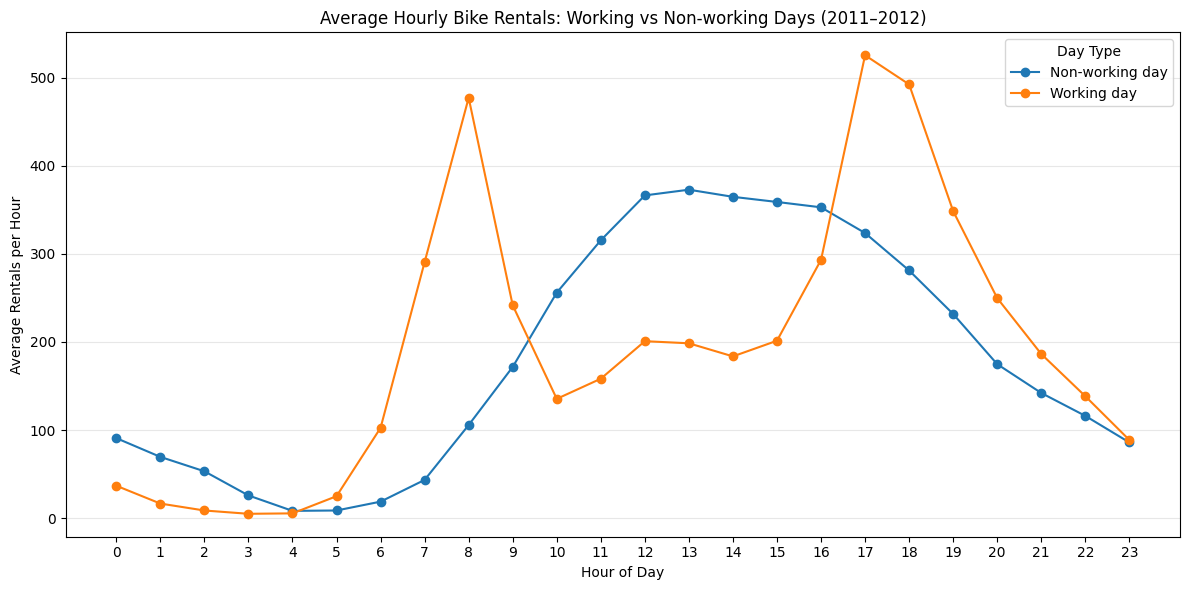

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
for label, grp in q1_summary.groupby("workingday_label"):
    ax.plot(grp["hr"], grp["avg_rentals"], marker="o", label=label)
ax.set_title("Average Hourly Bike Rentals: Working vs Non-working Days (2011–2012)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Rentals per Hour")
ax.set_xticks(range(0, 24))
ax.legend(title="Day Type")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight Visualisasi Pertanyaan 1:** Grafik menunjukkan dua pola yang jelas. Hari kerja memiliki dua lonjakan tajam pada jam komuter, terutama pukul 08.00 dan 17.00–18.00. Hari non-kerja cenderung meningkat secara bertahap dan mencapai puncak sekitar tengah hari sampai sore.

### Pertanyaan 2: Bagaimana kondisi cuaca memengaruhi permintaan?

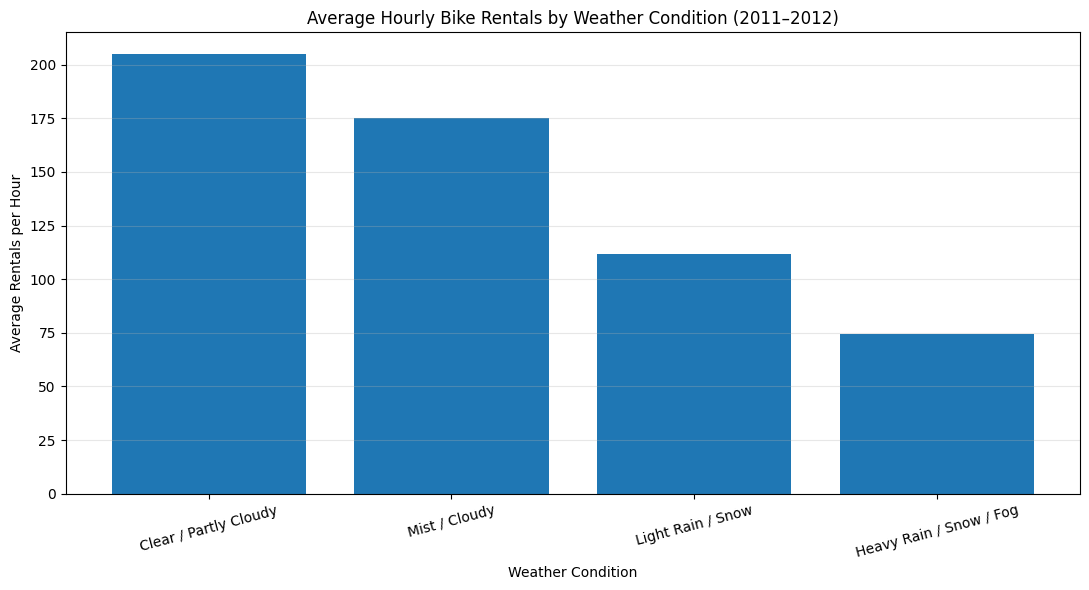

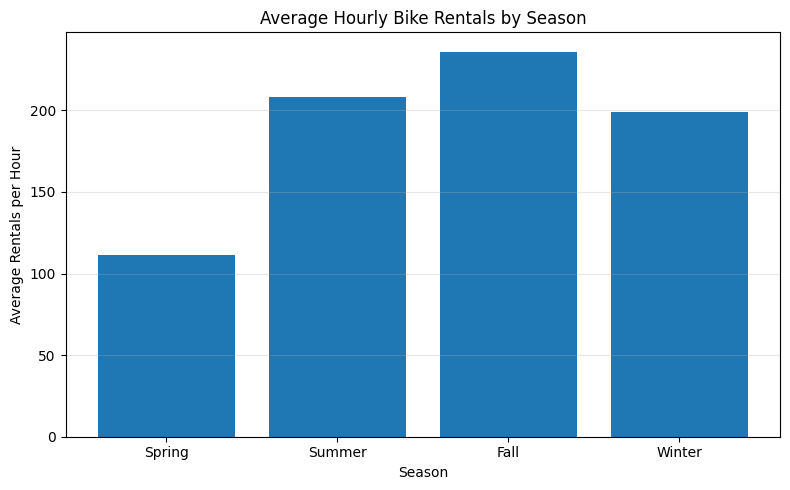

In [9]:
weather_plot = weather_summary.copy()
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(weather_plot["weather_label"], weather_plot["avg_rentals"])
ax.set_title("Average Hourly Bike Rentals by Weather Condition (2011–2012)")
ax.set_xlabel("Weather Condition")
ax.set_ylabel("Average Rentals per Hour")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Visual tambahan untuk memperkuat interpretasi musiman
season_order = ["Spring", "Summer", "Fall", "Winter"]
season_plot = (
    hour_df.groupby("season_label", observed=True)["cnt"]
    .mean().reindex(season_order).reset_index(name="avg_rentals")
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(season_plot["season_label"], season_plot["avg_rentals"])
ax.set_title("Average Hourly Bike Rentals by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Rentals per Hour")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight Visualisasi Pertanyaan 2:** Permintaan menurun seiring memburuknya kondisi cuaca. Perbedaan dari kondisi cerah ke hujan/salju ringan sangat besar, sehingga cuaca layak digunakan sebagai faktor operasional dalam menentukan jumlah sepeda yang perlu disiapkan. Visual musiman juga menunjukkan permintaan relatif kuat pada Fall dan Summer.

## Analisis Lanjutan: Manual Grouping / Binning Waktu

Untuk menambah nilai analisis tanpa machine learning, jam dikelompokkan menggunakan teknik **binning** menjadi lima periode operasional. Tujuannya adalah menyederhanakan 24 jam menjadi kelompok waktu yang lebih mudah digunakan untuk keputusan rebalancing sepeda dan penjadwalan petugas.

workingday_label,Non-working day,Working day
time_band,,
Early morning (00-05),43.0,16.4
Morning (06-09),85.0,277.9
Midday (10-15),338.9,179.7
Evening peak (16-19),297.3,414.8
Night (20-23),129.7,165.8


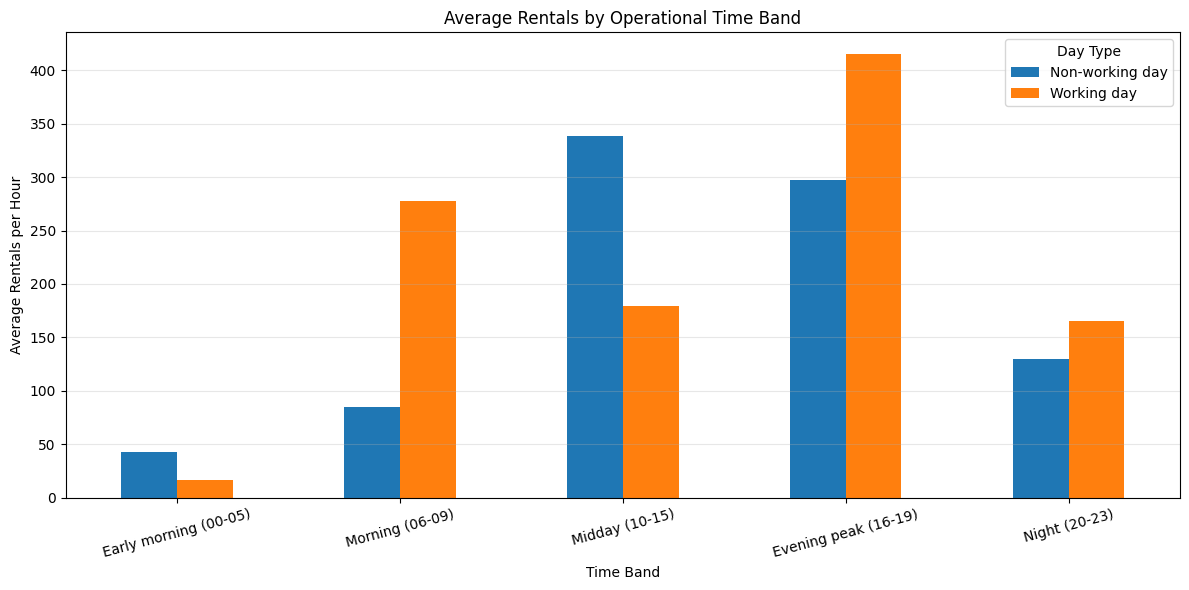

In [10]:
# Binning jam menjadi periode operasional
bins = [-1, 5, 9, 15, 19, 23]
labels = [
    "Early morning (00-05)",
    "Morning (06-09)",
    "Midday (10-15)",
    "Evening peak (16-19)",
    "Night (20-23)"
]
hour_df["time_band"] = pd.cut(hour_df["hr"], bins=bins, labels=labels)

time_band_summary = (
    hour_df.groupby(["time_band", "workingday_label"], observed=True)["cnt"]
    .mean().reset_index(name="avg_rentals")
)
display(time_band_summary.pivot(index="time_band", columns="workingday_label", values="avg_rentals").round(1))

pivot_plot = time_band_summary.pivot(index="time_band", columns="workingday_label", values="avg_rentals")
ax = pivot_plot.plot(kind="bar", figsize=(12, 6))
ax.set_title("Average Rentals by Operational Time Band")
ax.set_xlabel("Time Band")
ax.set_ylabel("Average Rentals per Hour")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Day Type")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight Analisis Lanjutan:**
- Pada hari kerja, kelompok **Evening peak (16–19)** memiliki rata-rata tertinggi, sekitar **415 penyewaan/jam**.
- Pada hari non-kerja, kelompok **Midday (10–15)** menjadi periode terkuat, sekitar **339 penyewaan/jam**.
- Binning ini memperjelas bahwa jadwal rebalancing tidak seharusnya sama untuk seluruh hari.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pola permintaan berbeda kuat antara hari kerja dan hari non-kerja. Pada hari kerja, puncak utama terjadi pukul **17.00** (sekitar **525 penyewaan/jam**) dan puncak pagi terlihat sekitar pukul **08.00**. Pada hari non-kerja, puncak terjadi sekitar pukul **13.00** (sekitar **373 penyewaan/jam**) dengan pola yang lebih menyebar pada siang–sore.
- **Conclusion pertanyaan 2:** Cuaca berhubungan erat dengan tingkat permintaan. Rata-rata penyewaan sekitar **205/jam** pada cuaca cerah, **175/jam** pada mist/cloudy, dan **112/jam** pada hujan/salju ringan. Artinya, hujan/salju ringan berkaitan dengan penurunan sekitar **45%** dibandingkan cuaca cerah. Kategori cuaca ekstrem memiliki data yang sangat sedikit sehingga perlu ditafsirkan hati-hati.

**Rekomendasi Action Item:**
1. **Hari kerja:** prioritaskan ketersediaan sepeda dan proses rebalancing **sebelum pukul 08.00** serta **sebelum pukul 17.00–18.00**, karena periode tersebut menunjukkan lonjakan komuter terbesar.
2. **Hari non-kerja:** alihkan fokus kapasitas ke **tengah hari hingga sore (sekitar 10.00–16.00)**, bukan mengikuti pola jam sibuk hari kerja.
3. **Berbasis cuaca:** pada prakiraan mist/cloudy, siapkan kapasitas moderat; pada hujan/salju ringan, kapasitas operasional dapat disesuaikan lebih rendah karena rata-rata permintaan historis turun sekitar 45% dibandingkan cuaca cerah. Tetap pertahankan kapasitas minimum untuk menjamin layanan.
4. Gunakan hasil **binning periode operasional** sebagai dasar jadwal rebalancing yang berbeda antara hari kerja dan hari non-kerja.